<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Wk_5_Ensembling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install imblearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
%matplotlib inline

In [32]:
df = pd.read_csv('/content/fitness_class_2212.csv')


print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (1500, 8)

First 5 Rows:


,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0


In [33]:
# Handle missing values
# Option 1: Drop rows with missing values
df = df.dropna()

# Option 2: Impute missing values
# imputer = SimpleImputer(strategy='mean')
# df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [34]:
#label encoding categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1480 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        1480 non-null   int64  
 1   months_as_member  1480 non-null   int64  
 2   weight            1480 non-null   float64
 3   days_before       1480 non-null   int64  
 4   day_of_week       1480 non-null   int64  
 5   time              1480 non-null   int64  
 6   category          1480 non-null   int64  
 7   attended          1480 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 104.1 KB


In [36]:
### EDA

df.describe()

,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000
mean,749.621622,15.659459,82.610378,13.236486,4.082432,0.236486,2.962162,0.303378
std,433.758225,12.971138,12.765859,9.389449,2.670038,0.425068,1.024342,0.459873
min,1.000000,1.000000,55.410000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,374.750000,8.000000,73.490000,5.000000,2.000000,0.000000,2.000000,0.000000
50%,749.500000,12.000000,80.760000,14.000000,5.000000,0.000000,3.000000,0.000000
75%,1126.250000,19.000000,89.520000,20.000000,6.000000,0.000000,3.000000,1.000000
max,1500.000000,148.000000,170.520000,30.000000,9.000000,1.000000,5.000000,1.000000


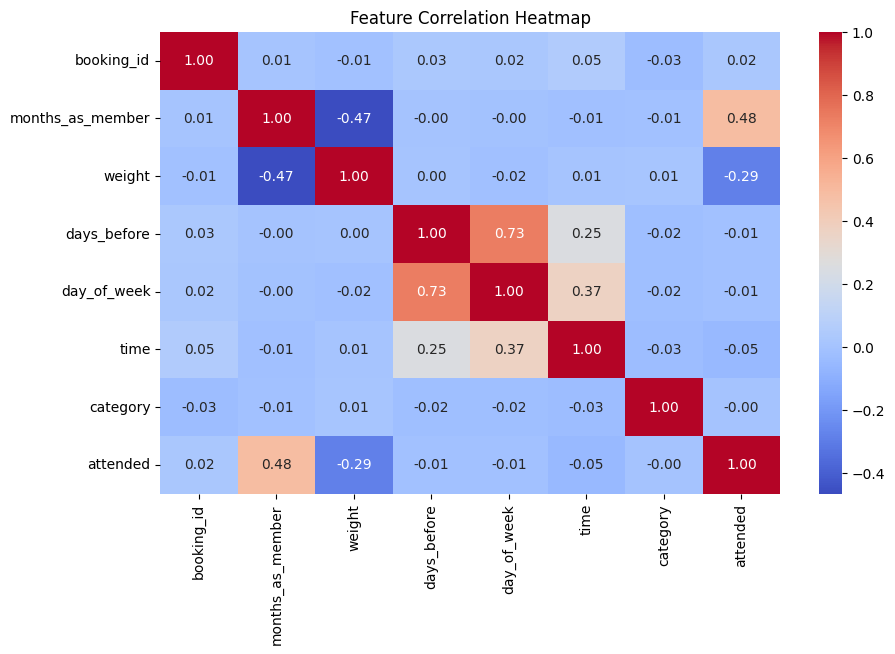

In [37]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

#most features show no noticeable correlation
# stronger -ve correlation between weight and member months
# stronger +ve correlation between days before and day of week

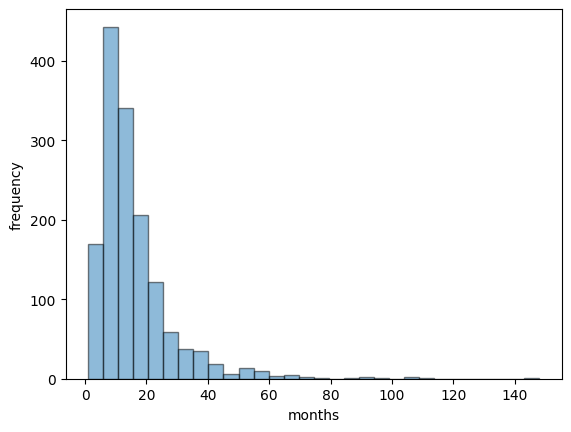

In [38]:
# months as a member - histogram

plt.hist(df['months_as_member'], bins=30, alpha=0.5, edgecolor='black')
plt.xlabel('months')
plt.ylabel('frequency')
plt.show()

# majority of people (400+ members) have been members between 0-15 months

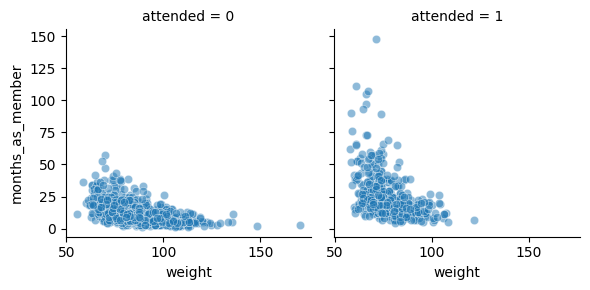

In [39]:
#relationships between weight, member months, attendance,  - scatter plots
g = sns.FacetGrid(df, col='attended');
g.map(sns.scatterplot, 'weight', 'months_as_member', alpha=0.5)

In [40]:
# bar chart grid for each day against class type (HIIT, Cycling, Strength, Yoga, Aqua)

print('number of samples in each fitness class:')
df['category'].value_counts()

number of samples in each fitness class:


,count
category,
3,657
2,370
4,231
5,135
1,74
0,13


In [41]:
#Preprocessing Dataset - label encoding
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [42]:
X = df.drop('category', axis=1)  # Replace 'Attendance' with your target column name
y = df['category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
#Balancing the Dataset (SMOTE: Oversampling using imblearn library)
#SMOTE inserts synthetic examples into the minority class to balance dataset
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [45]:
#Dataset is now balanced and scaled
#Logistic Regression
lr_balanced = LogisticRegression(random_state=42)
lr_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_lr_balanced = lr_balanced.predict(X_test_scaled)

print("\nLogistic Regression Performance (With Balancing):")
print(classification_report(y_test, y_pred_lr_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_balanced))

# misclassifications present


Logistic Regression Performance (With Balancing):
              precision    recall  f1-score   support

           0       0.02      0.33      0.03         6
           1       0.07      0.19      0.10        16
           2       0.23      0.17      0.19       109
           3       0.48      0.11      0.18       195
           4       0.18      0.29      0.22        72
           5       0.11      0.11      0.11        46

    accuracy                           0.16       444
   macro avg       0.18      0.20      0.14       444
weighted avg       0.31      0.16      0.18       444

Confusion Matrix:
[[ 2  0  1  1  1  1]
 [ 3  3  5  3  1  1]
 [22  8 18 11 38 12]
 [54 21 38 22 41 19]
 [22  7 11  4 21  7]
 [13  6  4  5 13  5]]


<Axes: >

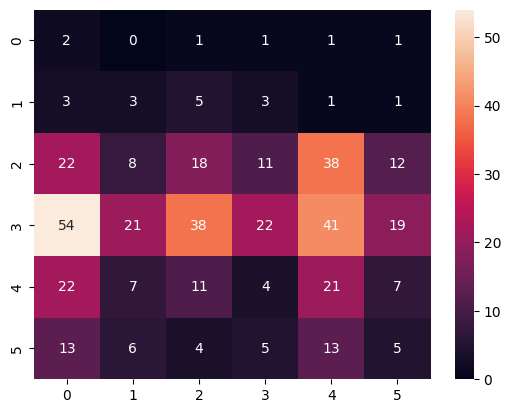

In [46]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_lr_balanced)
sns.heatmap(cm,annot=True)

In [47]:
#Random Forest Model
rf_balanced = RandomForestClassifier(random_state=42)
rf_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_rf_balanced = rf_balanced.predict(X_test_scaled)

print("\nRandom Forest Performance (With Balancing):")
print(classification_report(y_test, y_pred_rf_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))

#produced more misclassifications than Logistic Regression model


Random Forest Performance (With Balancing):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.02      0.06      0.03        16
           2       0.23      0.20      0.22       109
           3       0.43      0.42      0.43       195
           4       0.18      0.18      0.18        72
           5       0.11      0.09      0.10        46

    accuracy                           0.27       444
   macro avg       0.16      0.16      0.16       444
weighted avg       0.29      0.27      0.28       444

Confusion Matrix:
[[ 0  1  0  3  1  1]
 [ 0  1  5  8  1  1]
 [ 1 11 22 46 20  9]
 [ 3 22 44 82 29 15]
 [ 1  6 16 31 13  5]
 [ 2  3  8 20  9  4]]


<Axes: >

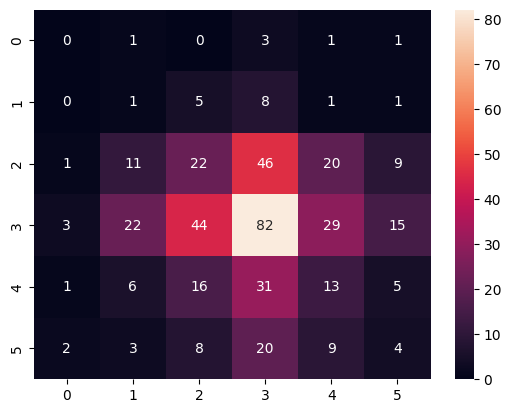

In [48]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_rf_balanced)
sns.heatmap(cm,annot=True)

In [55]:
#Hyperparameter Tuning (Random Forest)
#n_estimators = no. of decision trees used
#max_depth = maximum depth of each decision tree
#min_samples_split = min no. of features used within each split in decision tree
param_grid_rf = {
    'n_estimators': [100, 150, 250],
    'max_depth': [None, 5, 5],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_search_rf.fit(X_train_balanced, y_train_balanced)

print("\nBest Parameters for Random Forest:")
print(grid_search_rf.best_params_)

# Evaluate tuned Random Forest
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)

print("\nTuned Random Forest Performance:")
print(classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))


Best Parameters for Random Forest:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 250}

Tuned Random Forest Performance:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.02      0.06      0.03        16
           2       0.24      0.22      0.23       109
           3       0.44      0.43      0.43       195
           4       0.11      0.11      0.11        72
           5       0.14      0.11      0.12        46

    accuracy                           0.27       444
   macro avg       0.16      0.15      0.16       444
weighted avg       0.29      0.27      0.28       444

Confusion Matrix:
[[ 0  1  0  4  1  0]
 [ 0  1  5  8  1  1]
 [ 1  8 24 44 22 10]
 [ 3 22 45 83 29 13]
 [ 1  7 19 31  8  6]
 [ 2  3  6 20 10  5]]


In [50]:
#Cross-Validation (for Random Forest)
cv_scores_rf = cross_val_score(best_rf, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
print("\nRandom Forest Cross-Validation Scores:", cv_scores_rf)
print("Mean CV Accuracy:", cv_scores_rf.mean())
# higher cv scores indicate better generalization on unseen data (though variance of scores must be considered)


Random Forest Cross-Validation Scores: [0.65765766 0.6972973  0.71299639 0.79602888 0.76353791]
Mean CV Accuracy: 0.7255036263700523


In [54]:
###
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = best_rf.predict(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test_scaled, y_proba)
plt.plot(fpr, tpr, label=f'{'best rf'} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RF Best Features model')
plt.legend()
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [52]:
#Gradient Boosting Trees (GBT)
gbt = GradientBoostingClassifier(random_state=42)
gbt.fit(X_train_balanced, y_train_balanced)
y_pred_gbt = gbt.predict(X_test_scaled)

print("\nGradient Boosting Trees Performance:")
print(classification_report(y_test, y_pred_gbt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbt))


Gradient Boosting Trees Performance:
              precision    recall  f1-score   support

           0       0.07      0.17      0.10         6
           1       0.04      0.12      0.06        16
           2       0.29      0.22      0.25       109
           3       0.46      0.43      0.44       195
           4       0.10      0.10      0.10        72
           5       0.12      0.11      0.11        46

    accuracy                           0.27       444
   macro avg       0.18      0.19      0.18       444
weighted avg       0.30      0.27      0.29       444

Confusion Matrix:
[[ 1  0  0  3  2  0]
 [ 0  2  2  9  1  2]
 [ 1  9 24 44 22  9]
 [ 7 24 34 83 28 19]
 [ 3 14 15 27  7  6]
 [ 3  6  8 15  9  5]]


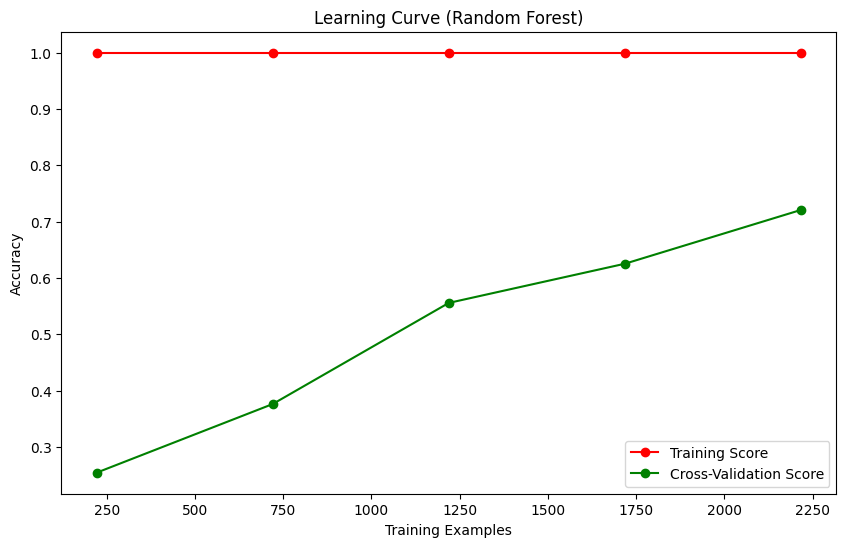

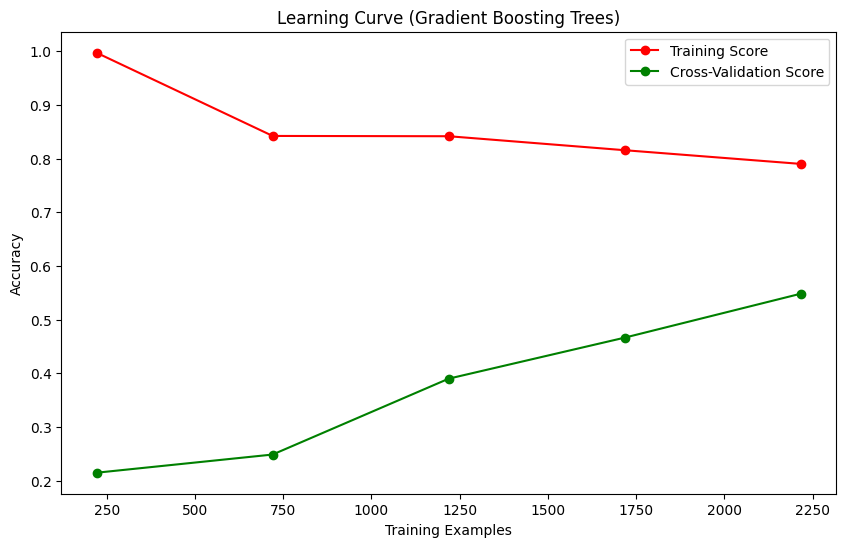

In [53]:
#Bias-Variance Tradeoff (Learning Curves)
#Learning curves detect whether a model is underfitting or overfitting - bias/variance trade off
#training curve = model performance on training/learning data
#validation curve = how well model performs on unseen data
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend(loc="best")
    plt.show()

# Plot learning curve for Random Forest
plot_learning_curve(best_rf, "Learning Curve (Random Forest)", X_train_balanced, y_train_balanced)

# Plot learning curve for Gradient Boosting Trees
plot_learning_curve(gbt, "Learning Curve (Gradient Boosting Trees)", X_train_balanced, y_train_balanced)